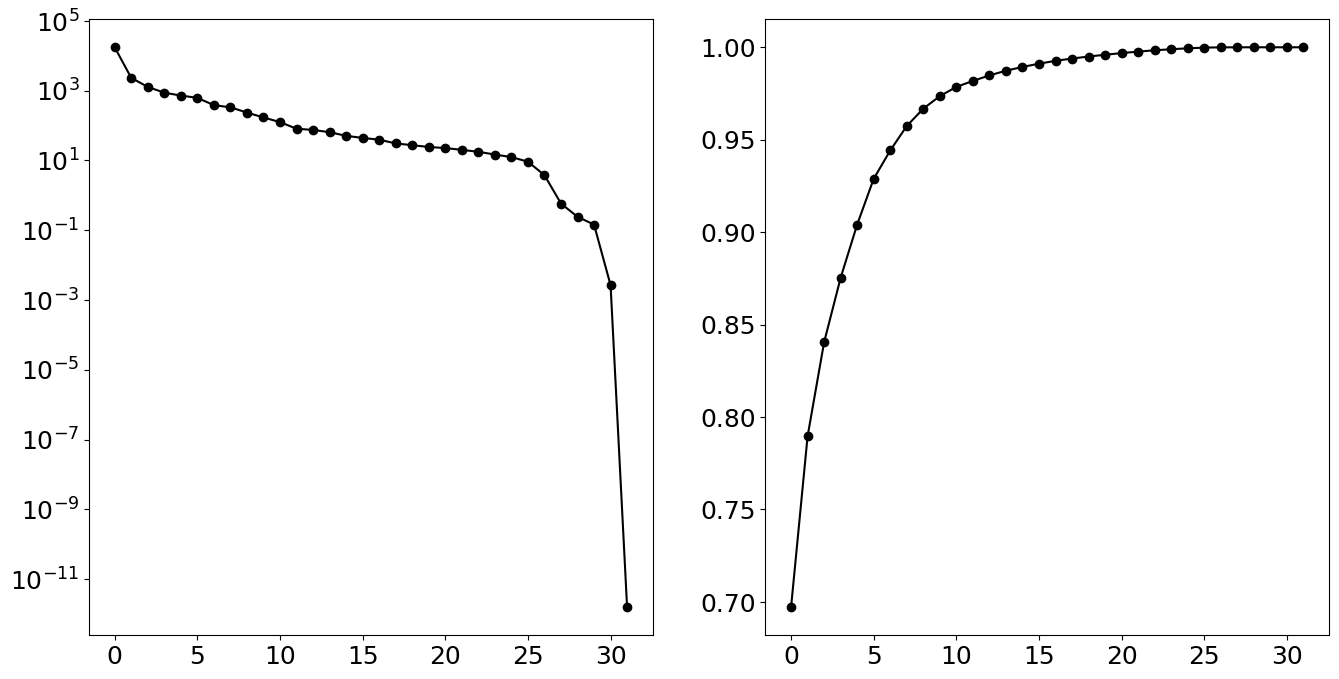

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import os
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams['figure.figsize'] = [16, 8]
plt.rcParams.update({'font.size': 18})


# 使用genfromtxt代替loadtxt，以便更好地处理缺失值
# 将"-"视为缺失值的一种表示方式
obs = np.genfromtxt(os.path.join('battery_raw.csv'), 
                   delimiter=',',
                   missing_values=['-','NA','N/A','na','n/a',''],
                   filling_values=np.nan)

# 计算每列的均值，忽略NaN值
col_mean = np.nanmean(obs, axis=0)
# 找出所有NaN值的位置
inds = np.where(np.isnan(obs))
if len(inds[0]) > 0:  
     obs[inds] = np.take(col_mean, inds[1])


f = open(os.path.join('battery_tg.csv'), "r")
grp = f.read().split("\n")

U, S, VT = np.linalg.svd(obs,full_matrices=0)

fig1 = plt.figure()
ax1 = fig1.add_subplot(121)
ax1.semilogy(S,'-o',color='k')
ax2 = fig1.add_subplot(122)
ax2.plot(np.cumsum(S)/np.sum(S),'-o',color='k')

plt.show()

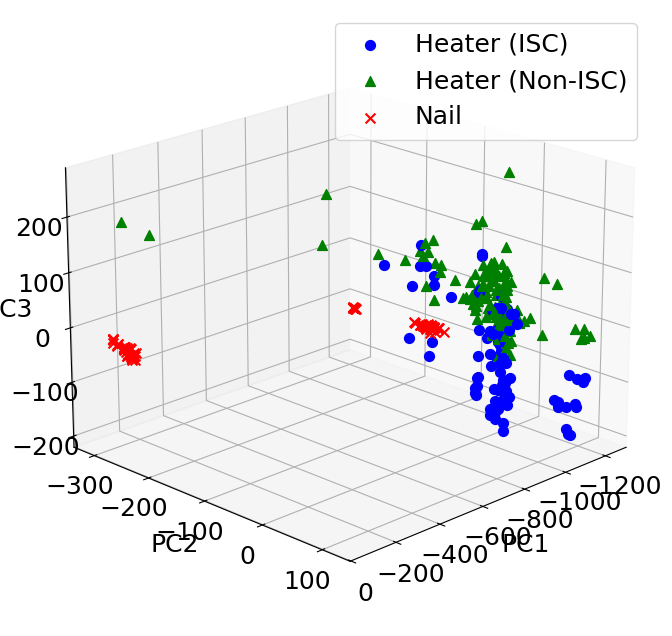

In [68]:
fig2 = plt.figure()
ax = fig2.add_subplot(111, projection='3d')

# 定义每个标签对应的颜色和标记
label_styles = {
    'Nail': {'color': 'r', 'marker': 'x'},
    'Heater (ISC)': {'color': 'b', 'marker': 'o'},
    'Heater (Non-ISC)': {'color': 'g', 'marker': '^'}  # 使用绿色和上三角形标记
}

# 为图例创建空列表
legend_elements = []

for j in range(obs.shape[0]):
    x = VT[0,:] @ obs[j,:].T
    y = VT[1,:] @ obs[j,:].T
    z = VT[2,:] @ obs[j,:].T
    
    # 获取当前样本的标签
    current_label = grp[j]
    
    # 检查标签是否在预定义的样式中
    if current_label in label_styles:
        style = label_styles[current_label]
        # 绘制散点图
        scatter = ax.scatter(x, y, z, 
                  marker=style['marker'], 
                  color=style['color'], 
                  s=50, 
                  label=current_label)
    else:
        # 对于未定义的标签，使用默认样式
        scatter = ax.scatter(x, y, z, marker='*', color='k', s=50, label=current_label)

# 设置视角
ax.view_init(20, 45)

# 添加图例（只显示每种标签一次）
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='best')

# 添加轴标签
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()